# CACE-SOG cumulene evaluation

This notebook mirrors the logic in `metrics_cumulene.py` and `results_cumulene.py` for the CACE-SOG model.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from ase.io import read
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
%env PYTHONPATH=/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM

env: PYTHONPATH=/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM


In [3]:
# Paths
WORKDIR = Path("/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/")
DATASET_DIR = Path("/data/home/public/qiuqizhi/LOREM/datasets")
MODEL_PATH = WORKDIR / "best_model.pth"
CACE_REPO = Path("/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM")
CACE_BUILD_LIB = CACE_REPO / "build/lib"

# Prefer source package; fallback to build/lib when source is incomplete.
if str(CACE_REPO) not in sys.path:
    sys.path.insert(0, str(CACE_REPO))

try:
    from cace.calculators import CACECalculator
except ModuleNotFoundError as exc:
    if "cace.data.atomic_data" not in str(exc):
        raise
    if str(CACE_BUILD_LIB) not in sys.path:
        sys.path.insert(0, str(CACE_BUILD_LIB))
    import importlib
    importlib.invalidate_caches()
    for mod_name in list(sys.modules):
        if mod_name == "cace" or mod_name.startswith("cace."):
            del sys.modules[mod_name]
    from cace.calculators import CACECalculator

device = "cuda"
print(f"Device: {device}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Dataset dir exists: {DATASET_DIR.exists()}")

Device: cuda
Model exists: True
Dataset dir exists: True


In [4]:
def assign_calculators(systems, calculator):
    for system in systems:
        system.calc = calculator


def order_by_dihedrals(systems, atom_indices=(0, 1, 11, 12)):
    dihedrals = []
    for system in systems:
        dihedrals.append(system.get_dihedral(*atom_indices))
    dihedrals = np.array(dihedrals)
    order = np.argsort(dihedrals)
    systems[:] = [systems[i] for i in order]
    return dihedrals[order]


def get_energies(systems):
    energies = [system.get_potential_energy() for system in systems]
    min_energy = min(energies)
    return [energy - min_energy for energy in energies]


def plot_results(dihedrals, predicted_energies, actual_energies, output_path, label):
    plt.figure(figsize=(10, 6))
    plt.plot(dihedrals, predicted_energies, label="Predicted energies", alpha=0.7)
    plt.plot(dihedrals, actual_energies, label="Energies from DFT", alpha=0.7)
    plt.xlabel("Dihedral Angle (degrees)")
    plt.ylabel("Potential Energy (eV)")
    plt.legend()
    plt.title(f"Energy vs. Dihedral Angle ({label})")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.show()

In [5]:
# Build calculator for combined CACE-SOG model output
# IMPORTANT: CACECalculator.__init__ always calls self.model.to(device),
# so passing `device='cuda'` can still OOM even if torch.load used map_location='cpu'.
model = torch.load(str(MODEL_PATH), map_location='cpu', weights_only=False)
model.eval()

requested_device = device  # from previous cell
calc_device = requested_device

try:
    if requested_device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.empty_cache()
    calculator = CACECalculator(
        model_path=model,
        device=calc_device,
        properties=[
            {
                "energy": "CACE_energy",
                "forces": "CACE_forces",
                "weight": 1.0,
            }
        ],
    )
except RuntimeError as e:
    if "out of memory" in str(e).lower() and requested_device.startswith("cuda"):
        print("CUDA OOM when moving model to GPU. Fallback to CPU calculator.")
        calc_device = "cpu"
        calculator = CACECalculator(
            model_path=model,
            device=calc_device,
            properties=[
                {
                    "energy": "CACE_energy",
                    "forces": "CACE_forces",
                    "weight": 1.0,
                }
            ],
        )
    else:
        raise

print(f"Calculator is ready on device: {calc_device}")

CUDA version: 12.4, CUDA device: 0
Calculator is ready on device: cuda


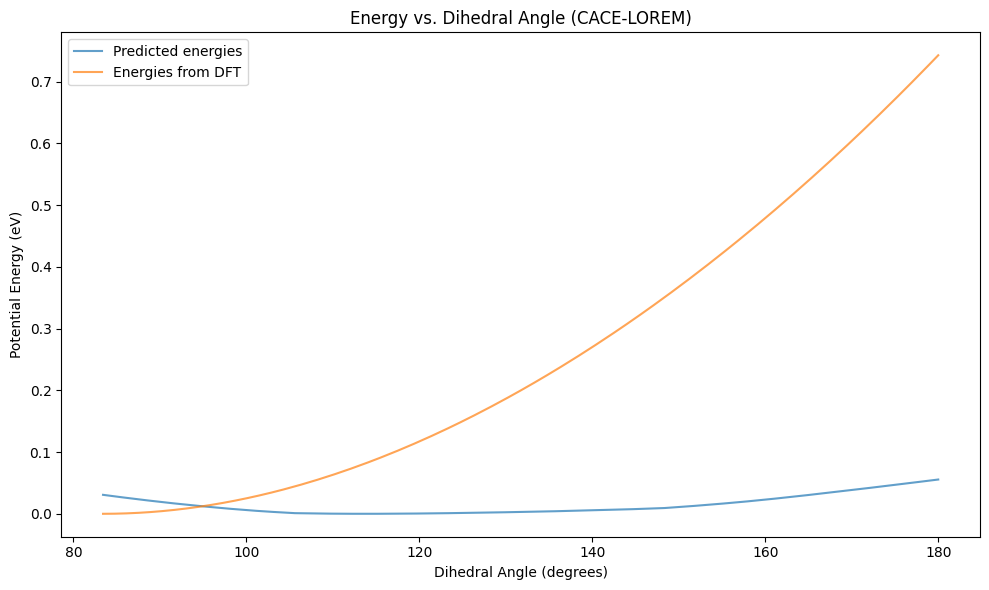

Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/cumulene_dihedral_energy_curve.png
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/cumulene_dihedral_energy_curve.npz


In [6]:
# 1) Dihedral energy curve (results_cumulene.py equivalent)
systems_profile = read(DATASET_DIR / "cumulene_profile.xyz", index=":")
dihedrals = order_by_dihedrals(systems_profile)
actual_energies = get_energies(systems_profile)
assign_calculators(systems_profile, calculator)
predicted_energies = get_energies(systems_profile)

curve_png_path = WORKDIR  /"cumulene_dihedral_energy_curve.png"
curve_npz_path = WORKDIR  /"cumulene_dihedral_energy_curve.npz"

plot_results(
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
    output_path=curve_png_path,
    label="CACE-LOREM",
)

np.savez(
    curve_npz_path,
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
)

print(f"Saved: {curve_png_path}")
print(f"Saved: {curve_npz_path}")

In [7]:
# 1.5) Per-structure multipole/energy breakdown on dihedral profile
# This directly checks whether LR branch carries dihedral-shape information.
import pandas as pd
from cace.data import AtomicData
from cace.tools import torch_geometric


def _to_graph_dict(atoms, cutoff, device):
    atoms_for_graph = atoms.copy()
    if "energy" not in atoms_for_graph.info:
        atoms_for_graph.info["energy"] = 0.0
    if "forces" not in atoms_for_graph.arrays:
        atoms_for_graph.arrays["forces"] = np.zeros((len(atoms_for_graph), 3), dtype=float)

    loader = torch_geometric.dataloader.DataLoader(
        dataset=[AtomicData.from_atoms(atoms_for_graph, cutoff=cutoff)],
        batch_size=1,
        shuffle=False,
        drop_last=False,
    )
    batch = next(iter(loader)).to(device)
    return batch.to_dict()


def _as_numpy(x):
    return x.detach().cpu().numpy()


systems_profile_eval = read(DATASET_DIR / "cumulene_profile.xyz", index=":")
dihedrals_eval = order_by_dihedrals(systems_profile_eval)

lr_weight = 1.0
if hasattr(model, "potential_keys") and len(model.potential_keys) > 1 and "weight" in model.potential_keys[1]:
    lr_weight = float(model.potential_keys[1]["weight"])
print(f"Using effective LR weight from combined model: {lr_weight}")

summary_rows = []
atom_rows = []

for sid, atoms in enumerate(systems_profile_eval):
    graph_dict = _to_graph_dict(atoms, cutoff=calculator.cutoff, device=calc_device)

    with torch.enable_grad():
        out_total = model(graph_dict, training=False)
        out_lr = model.models[1](graph_dict, training=False)

    q_all = _as_numpy(out_lr["q"])
    q0 = _as_numpy(out_lr.get("q_monopole", out_lr["q"][:, :1]))
    q1 = _as_numpy(out_lr.get("q_dipole", out_lr["q"][:, 1:4]))
    q2 = _as_numpy(out_lr.get("q_quadrupole", out_lr["q"][:, 4:9]))

    q1_norm = np.linalg.norm(q1, axis=1)
    q2_norm = np.linalg.norm(q2, axis=1)

    e_total = float(_as_numpy(out_total["CACE_energy"]).reshape(-1)[0])
    e_long_raw = float(_as_numpy(out_lr["lr_energy"]).reshape(-1)[0])
    e_long = lr_weight * e_long_raw
    e_short = e_total - e_long

    f_total = _as_numpy(out_total["CACE_forces"]).reshape(-1, 3)
    f_long = lr_weight * _as_numpy(out_lr["SOG_forces"]).reshape(-1, 3)
    f_total_norm = np.linalg.norm(f_total, axis=1).sum()
    f_long_norm = np.linalg.norm(f_long, axis=1).sum()
    f_ratio = float(f_long_norm / max(f_total_norm, 1e-12))

    z_list = atoms.get_atomic_numbers()
    for ai in range(len(atoms)):
        atom_rows.append(
            {
                "struct_id": sid,
                "dihedral_deg": float(dihedrals_eval[sid]),
                "atom_index": ai,
                "Z": int(z_list[ai]),
                "q0": float(q0[ai, 0]),
                "q1_x": float(q1[ai, 0]),
                "q1_y": float(q1[ai, 1]),
                "q1_z": float(q1[ai, 2]),
                "q1_norm": float(q1_norm[ai]),
                "q2_0": float(q2[ai, 0]),
                "q2_1": float(q2[ai, 1]),
                "q2_2": float(q2[ai, 2]),
                "q2_3": float(q2[ai, 3]),
                "q2_4": float(q2[ai, 4]),
                "q2_norm": float(q2_norm[ai]),
            }
        )

    summary_rows.append(
        {
            "struct_id": sid,
            "dihedral_deg": float(dihedrals_eval[sid]),
            "n_atoms": int(len(atoms)),
            "e_total": e_total,
            "e_short_eff": e_short,
            "e_long_eff": e_long,
            "e_long_raw": e_long_raw,
            "f_long_over_f_total": f_ratio,
            "q0_mean": float(q0.mean()),
            "q0_abs_mean": float(np.abs(q0).mean()),
            "q0_std": float(q0.std()),
            "q1_norm_mean": float(q1_norm.mean()),
            "q1_norm_max": float(q1_norm.max()),
            "q2_norm_mean": float(q2_norm.mean()),
            "q2_norm_max": float(q2_norm.max()),
            "q_abs_mean_all_channels": float(np.abs(q_all).mean()),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("dihedral_deg").reset_index(drop=True)
atom_df = pd.DataFrame(atom_rows).sort_values(["dihedral_deg", "atom_index"]).reset_index(drop=True)

summary_csv = WORKDIR / "cumulene_dihedral_multipole_energy_summary.csv"
atom_csv = WORKDIR / "cumulene_dihedral_multipole_per_atom.csv"
summary_df.to_csv(summary_csv, index=False)
atom_df.to_csv(atom_csv, index=False)

print(f"Saved: {summary_csv}")
print(f"Saved: {atom_csv}")
print("\nSummary preview:")
display(summary_df.head(10))

print("\nQuick diagnostics:")
print("dihedral e_long_eff amplitude:", float(summary_df["e_long_eff"].max() - summary_df["e_long_eff"].min()))
print("dihedral e_short_eff amplitude:", float(summary_df["e_short_eff"].max() - summary_df["e_short_eff"].min()))
print("dihedral e_total amplitude:", float(summary_df["e_total"].max() - summary_df["e_total"].min()))
print("mean f_long_over_f_total:", float(summary_df["f_long_over_f_total"].mean()))

Using effective LR weight from combined model: 10.0
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/cumulene_dihedral_multipole_energy_summary.csv
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/cumulene_dihedral_multipole_per_atom.csv

Summary preview:


,struct_id,dihedral_deg,n_atoms,e_total,e_short_eff,e_long_eff,e_long_raw,f_long_over_f_total,q0_mean,q0_abs_mean,q0_std,q1_norm_mean,q1_norm_max,q2_norm_mean,q2_norm_max,q_abs_mean_all_channels
0,0,83.424819,13,-2.239533,2.122983,-4.362516,-0.436252,1.062218,-1.180427,1.180427,0.002244,4.188038,10.642721,12.523528,18.392527,2.997334
1,1,83.513758,13,-2.239701,2.122981,-4.362683,-0.436268,1.062209,-1.180427,1.180427,0.002244,4.189273,10.649610,12.522919,18.388594,2.997490
2,2,83.602712,13,-2.239865,2.122981,-4.362845,-0.436285,1.062208,-1.180427,1.180427,0.002244,4.190507,10.656486,12.522312,18.384644,2.997644
3,3,83.691682,13,-2.240034,2.122979,-4.363012,-0.436301,1.062202,-1.180427,1.180427,0.002244,4.191739,10.663354,12.521705,18.380676,2.997798
4,4,83.780669,13,-2.240193,2.122983,-4.363177,-0.436318,1.062198,-1.180427,1.180427,0.002244,4.192969,10.670208,12.521097,18.376684,2.997952
5,5,83.869671,13,-2.240357,2.122986,-4.363343,-0.436334,1.062195,-1.180427,1.180427,0.002244,4.194198,10.677052,12.520489,18.372669,2.998104
6,6,83.958688,13,-2.240524,2.122979,-4.363503,-0.436350,1.062186,-1.180428,1.180428,0.002244,4.195424,10.683883,12.519882,18.368635,2.998255
7,7,84.047723,13,-2.240686,2.122984,-4.363670,-0.436367,1.062179,-1.180428,1.180428,0.002244,4.196650,10.690707,12.519276,18.364586,2.998407
8,8,84.136773,13,-2.240850,2.122982,-4.363832,-0.436383,1.062175,-1.180428,1.180428,0.002244,4.197872,10.697509,12.518666,18.360504,2.998556
9,9,84.225839,13,-2.241017,2.122982,-4.363998,-0.436400,1.062164,-1.180428,1.180428,0.002244,4.199093,10.704308,12.518061,18.356411,2.998706



Quick diagnostics:
dihedral e_long_eff amplitude: 0.05590617656707764
dihedral e_short_eff amplitude: 0.0005353689193725586
dihedral e_total amplitude: 0.05551767349243164
mean f_long_over_f_total: 1.049401503920555


In [8]:
# 2) Metrics on test set (with absolute + offset-corrected + relative-energy metrics)
systems_test = read(DATASET_DIR / "cumulene_test.xyz", index=":")

energy_reference = np.array([system.get_potential_energy() / len(system) for system in systems_test], dtype=float)
forces_reference = [system.get_forces() for system in systems_test]

assign_calculators(systems_test, calculator)
energy_pred = np.array([system.get_potential_energy() / len(system) for system in systems_test], dtype=float)
forces_pred = [system.get_forces() for system in systems_test]

# A) Absolute energy metrics (sensitive to constant offset)
energy_rmse_abs = np.sqrt(mean_squared_error(energy_reference, energy_pred))
energy_mae_abs = mean_absolute_error(energy_reference, energy_pred)

# B) Offset-corrected metrics (remove one global constant bias)
energy_offset = float(np.mean(energy_reference - energy_pred))
energy_pred_aligned = energy_pred + energy_offset
energy_rmse_aligned = np.sqrt(mean_squared_error(energy_reference, energy_pred_aligned))
energy_mae_aligned = mean_absolute_error(energy_reference, energy_pred_aligned)

# C) Relative-energy-surface metrics (shape quality; common for dihedral/profile)
energy_reference_rel = energy_reference - np.min(energy_reference)
energy_pred_rel = energy_pred - np.min(energy_pred)
energy_rmse_rel = np.sqrt(mean_squared_error(energy_reference_rel, energy_pred_rel))
energy_mae_rel = mean_absolute_error(energy_reference_rel, energy_pred_rel)

forces_reference_flat = np.concatenate(forces_reference, axis=0)
forces_pred_flat = np.concatenate(forces_pred, axis=0)
forces_rmse = np.sqrt(mean_squared_error(forces_reference_flat, forces_pred_flat))
forces_mae = mean_absolute_error(forces_reference_flat, forces_pred_flat)

print(f"Energy RMSE (absolute):        {energy_rmse_abs * 1000:.6f} meV/atom")
print(f"Energy MAE  (absolute):        {energy_mae_abs * 1000:.6f} meV/atom")
print(f"Energy offset (ref - pred):    {energy_offset * 1000:.6f} meV/atom")
print(f"Energy RMSE (offset-correct):  {energy_rmse_aligned * 1000:.6f} meV/atom")
print(f"Energy MAE  (offset-correct):  {energy_mae_aligned * 1000:.6f} meV/atom")
print(f"Energy RMSE (relative surface): {energy_rmse_rel * 1000:.6f} meV/atom")
print(f"Energy MAE  (relative surface): {energy_mae_rel * 1000:.6f} meV/atom")
print(f"Forces RMSE:                   {forces_rmse * 1000:.6f} meV/A")
print(f"Forces MAE:                    {forces_mae * 1000:.6f} meV/A")

metrics_path = WORKDIR / "metrics.npz"
np.savez(
    metrics_path,
    # Keep legacy keys for compatibility
    energy_rmse=energy_rmse_abs * 1000,
    energy_mae=energy_mae_abs * 1000,
    forces_rmse=forces_rmse * 1000,
    forces_mae=forces_mae * 1000,
    # New explicit keys
    energy_offset_mev_per_atom=energy_offset * 1000,
    energy_rmse_abs_mev_per_atom=energy_rmse_abs * 1000,
    energy_mae_abs_mev_per_atom=energy_mae_abs * 1000,
    energy_rmse_aligned_mev_per_atom=energy_rmse_aligned * 1000,
    energy_mae_aligned_mev_per_atom=energy_mae_aligned * 1000,
    energy_rmse_rel_mev_per_atom=energy_rmse_rel * 1000,
    energy_mae_rel_mev_per_atom=energy_mae_rel * 1000,
)
print(f"Saved: {metrics_path}")

Energy RMSE (absolute):        4951.999325 meV/atom
Energy MAE  (absolute):        4951.969369 meV/atom
Energy offset (ref - pred):    -4951.969369 meV/atom
Energy RMSE (offset-correct):  17.224472 meV/atom
Energy MAE  (offset-correct):  13.976432 meV/atom
Energy RMSE (relative surface): 20.531545 meV/atom
Energy MAE  (relative surface): 14.797393 meV/atom
Forces RMSE:                   183.896688 meV/A
Forces MAE:                    140.148610 meV/A
Saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_ABtest5_strict/metrics.npz
